# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **Conduct EDA: visualization and statistical measures to understand the structure of the data.**
- **Recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request.**
- **Discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
#Load the data as cleaned_df:
cleaned_df = pd.read_csv("data/AviationDataCleaned.csv")
cleaned_df.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Aircraft.damage,Aircraft.Category,Registration.Number,Make,...,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Total.Passengers,Serious.or.Fatal.Fraction,Aircraft.Destroyed,Make.Model
0,20001214X42478,Incident,LAX83IA149B,1983-03-18,"LOS ANGELES, CA",United States,Minor,Airplane,N323EA,OTHER,...,0.0,0.0,0.0,588.0,VMC,Other,588.0,0.0,False,OTHER L-1011
1,20001214X42478,Incident,LAX83IA149A,1983-03-18,"LOS ANGELES, CA",United States,Minor,Airplane,9VSQQ,BOEING,...,0.0,0.0,0.0,588.0,VMC,Taxi,588.0,0.0,False,BOEING 747
2,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,Destroyed,Airplane,N9600W,PIPER,...,1.0,1.0,0.0,0.0,IMC,Cruise,2.0,1.0,True,PIPER PA-28-140
3,20001214X44248,Incident,MIA83IA210,1983-08-21,"NORFOLK, VA",United States,Minor,Airplane,N69NA,OTHER,...,0.0,0.0,0.0,289.0,VMC,Cruise,289.0,0.0,False,OTHER DC-10-10
4,20001214X44100,Accident,DCA83AA036,1983-08-21,"SILVANA, WA",United States,Destroyed,Airplane,N116CA,OTHER,...,11.0,2.0,0.0,13.0,VMC,Other,26.0,0.5,True,"OTHER LEARSTAR, L-18-56"


## Explore Safety Metrics Across Models/Makes
Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Set the passenger threshold to 20 and separate the plane types. 

In [3]:
#Let's create a new column called "Airplane.Size" that categorizes planes with
#greater than 20 passengers as "Large" and planes with fewer than 20 passengers
#as "Small":
cleaned_df["Airplane.Size"] = np.where(cleaned_df["Total.Passengers"] > 20, "Large", "Small")
#Check if it worked:
cleaned_df["Airplane.Size"].value_counts()

Airplane.Size
Small    19665
Large      539
Name: count, dtype: int64

#### Analyzing Makes

Explore the human injury risk profile for small and large Makes:
- Choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction.
- Plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side.

In [4]:
#First, group the data of Serious.or.Fatal.Fraction first by Airplane.Size, and 
#then by Make:
injury_risk_by_make_and_size = cleaned_df.groupby(["Airplane.Size", "Make"])["Serious.or.Fatal.Fraction"].mean()
injury_risk_by_make_and_size.head(20)

Airplane.Size  Make                      
Large          AIRBUS                        0.164951
               BEECH                         1.000000
               BOEING                        0.100822
               DEHAVILLAND                   0.181536
               EMBRAER                       0.104508
               MCDONNELL DOUGLAS             0.008176
               OTHER                         0.149506
Small          AERO COMMANDER                0.401685
               AERONCA                       0.225833
               AIR TRACTOR                   0.339120
               AIRBUS                        0.073171
               AMERICAN CHAMPION AIRCRAFT    0.274510
               AVIAT                         0.269499
               AYRES                         0.270833
               BEECH                         0.377015
               BELLANCA                      0.223624
               BOEING                        0.087551
               CESSNA                   

In [5]:
#Now, find the top 15 small planes with the lowest average injury risk:
small_makes_injury_risk = injury_risk_by_make_and_size["Small"].sort_values().head(15)
small_makes_injury_risk

Make
MCDONNELL DOUGLAS             0.072394
AIRBUS                        0.073171
BOEING                        0.087551
MAULE                         0.164806
STINSON                       0.216408
DIAMOND AIRCRAFT IND INC      0.222973
BELLANCA                      0.223624
AERONCA                       0.225833
CHAMPION                      0.262208
CESSNA                        0.262789
AVIAT                         0.269499
AYRES                         0.270833
LUSCOMBE                      0.273381
AMERICAN CHAMPION AIRCRAFT    0.274510
ROCKWELL                      0.281553
Name: Serious.or.Fatal.Fraction, dtype: float64

In [6]:
#Do the same for the top 15 large planes:
large_makes_injury_risk = injury_risk_by_make_and_size["Large"].sort_values().head(15)
large_makes_injury_risk

Make
MCDONNELL DOUGLAS    0.008176
BOEING               0.100822
EMBRAER              0.104508
OTHER                0.149506
AIRBUS               0.164951
DEHAVILLAND          0.181536
BEECH                1.000000
Name: Serious.or.Fatal.Fraction, dtype: float64

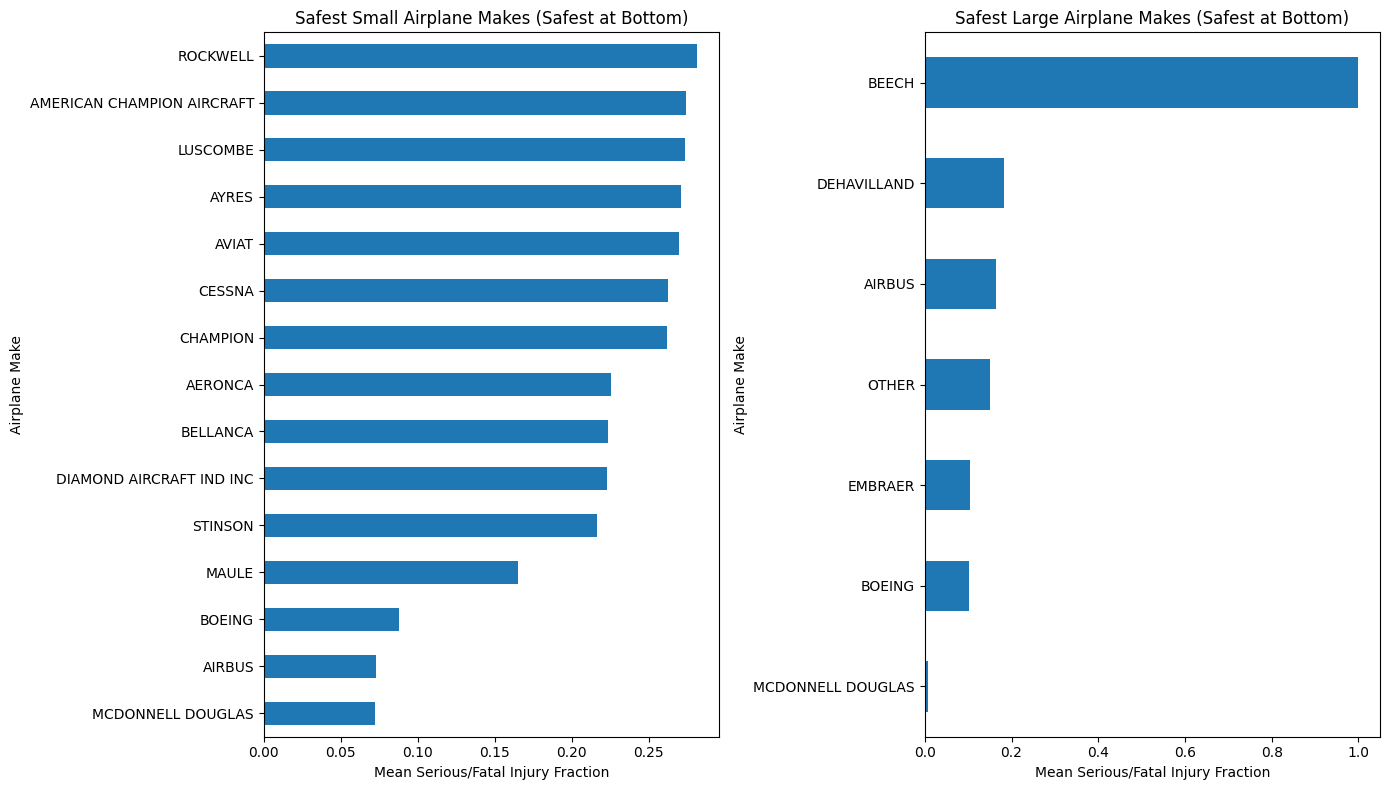

In [7]:
#Create side-by-side subplots:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (14, 8))

#Plot small airplane makes:
small_makes_injury_risk.sort_values().plot(kind = "barh", ax = axes[0])

axes[0].set_title("Safest Small Airplane Makes (Safest at Bottom)")
axes[0].set_xlabel("Mean Serious/Fatal Injury Fraction")
axes[0].set_ylabel("Airplane Make")

#Plot large airplane makes:
large_makes_injury_risk.sort_values().plot(kind = "barh", ax = axes[1])

axes[1].set_title("Safest Large Airplane Makes (Safest at Bottom)")
axes[1].set_xlabel("Mean Serious/Fatal Injury Fraction")
axes[1].set_ylabel("Airplane Make")

#Improve spacing:
plt.tight_layout()

#Show plots:
plt.show()

It's virtually impossible for BEECH to have a 100% chance of serious or fatal injury. Likely there are only one or two recorded incidents with BEECH, and every passenger had a serious or fatal injury each time. But this is likely statistically insignificant for BEECH. Looks like MCDONNELL DOUGLAS and BOEING are both pretty safe options for both large and small airplanes. AIRBUS looks safer for small planes than large planes.

**Distribution of injury rates: small makes**

Use a violin plot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

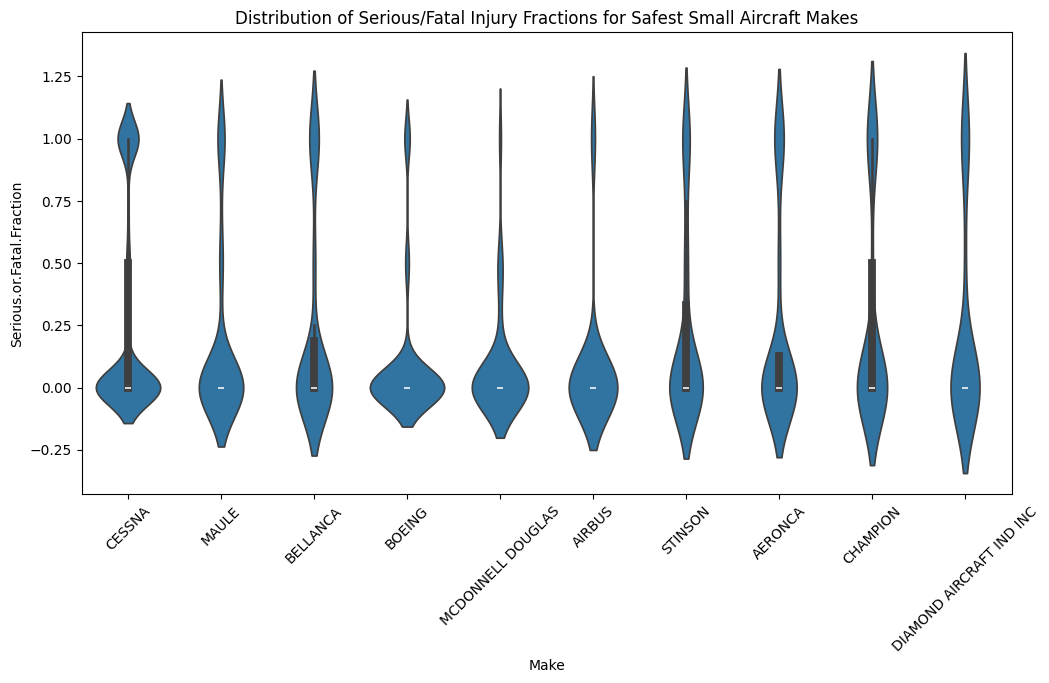

In [8]:
#First, get the ten safest small planes:
top_10_small = small_makes_injury_risk.head(10).index

#Now, create a df that we'll use to make the violin plot:
small_violin_df = cleaned_df[(cleaned_df["Airplane.Size"] == "Small") & (cleaned_df["Make"].isin(top_10_small))]

#Now, let's make the violin plot:
plt.figure(figsize = (12, 6))
sns.violinplot(data = small_violin_df, x = "Make", y = "Serious.or.Fatal.Fraction")
plt.title("Distribution of Serious/Fatal Injury Fractions for Safest Small Aircraft Makes")
plt.xticks(rotation = 45)
plt.show()

**Distribution of injury rates: large makes**

Use a strip plot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

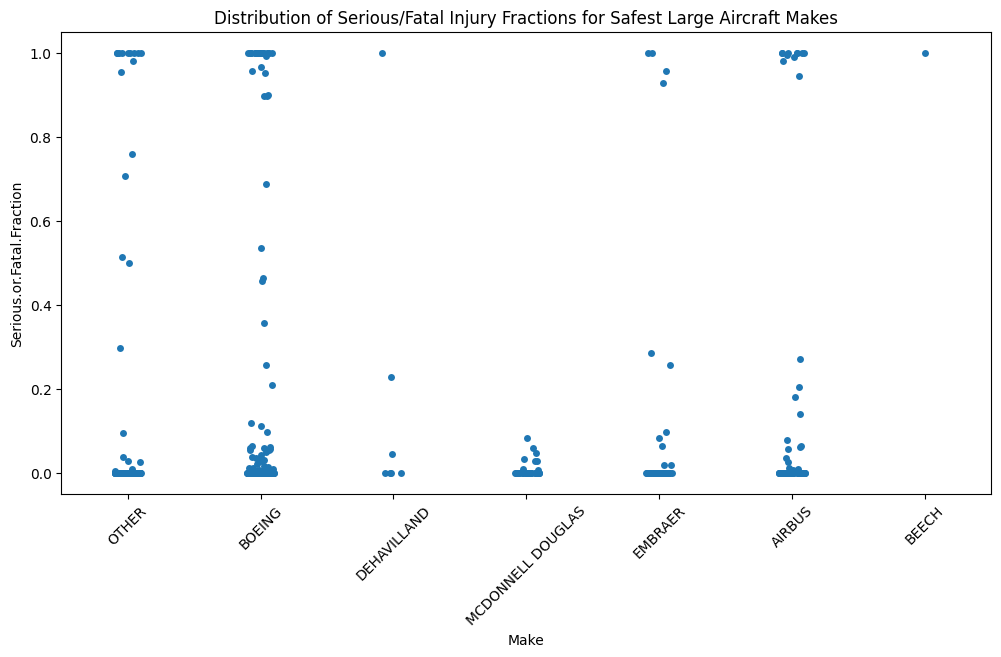

In [9]:
#First, get the ten safest large planes:
top_10_large = large_makes_injury_risk.head(10).index

#Now, create a df that we'll use to make the strip plot:
large_strip_plot_df = cleaned_df[(cleaned_df["Airplane.Size"] == "Large") & (cleaned_df["Make"].isin(top_10_large))]

#Now, let's make the strip plot:
plt.figure(figsize = (12, 6))
sns.stripplot(data = large_strip_plot_df, x = "Make", y = "Serious.or.Fatal.Fraction")
plt.title("Distribution of Serious/Fatal Injury Fractions for Safest Large Aircraft Makes")
plt.xticks(rotation = 45)
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make** 

Sort your results and keep the lowest 15.

In [10]:
#First, group the data of "Aircraft.Destroyed" first by Airplane.Size, and then group by Make:
destroyed_risk_by_make_and_size = cleaned_df.groupby(["Airplane.Size", "Make"])["Aircraft.Destroyed"].mean()
destroyed_risk_by_make_and_size.head(20)

Airplane.Size  Make                      
Large          AIRBUS                        0.164384
               BEECH                         1.000000
               BOEING                        0.095070
               DEHAVILLAND                   0.142857
               EMBRAER                       0.088889
               MCDONNELL DOUGLAS             0.111111
               OTHER                         0.161290
Small          AERO COMMANDER                0.146067
               AERONCA                       0.035000
               AIR TRACTOR                   0.136574
               AIRBUS                        0.073171
               AMERICAN CHAMPION AIRCRAFT    0.039216
               AVIAT                         0.102767
               AYRES                         0.135417
               BEECH                         0.181880
               BELLANCA                      0.050459
               BOEING                        0.066339
               CESSNA                   

In [11]:
#Now, find the top 15 small planes with the lowest rate of airplane destruction:
small_makes_destroyed_risk = destroyed_risk_by_make_and_size["Small"].sort_values().head(15)
small_makes_destroyed_risk

Make
LUSCOMBE                      0.014388
STINSON                       0.023256
TAYLORCRAFT                   0.032258
AERONCA                       0.035000
ERCOUPE                       0.038462
AMERICAN CHAMPION AIRCRAFT    0.039216
MAULE                         0.041860
BELLANCA                      0.050459
DIAMOND AIRCRAFT IND INC      0.054054
BOEING                        0.066339
AIRBUS                        0.073171
CHAMPION                      0.076433
FLIGHT DESIGN                 0.077922
CESSNA                        0.096942
AVIAT                         0.102767
Name: Aircraft.Destroyed, dtype: float64

In [12]:
#Do the same for the top 15 large planes:
large_makes_destroyed_risk = destroyed_risk_by_make_and_size["Large"].sort_values().head(15)
large_makes_destroyed_risk

Make
EMBRAER              0.088889
BOEING               0.095070
MCDONNELL DOUGLAS    0.111111
DEHAVILLAND          0.142857
OTHER                0.161290
AIRBUS               0.164384
BEECH                1.000000
Name: Aircraft.Destroyed, dtype: float64

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured.
- Comment on the calculated statistics and any corresponding distributions you have visualized.

Based on the serious/fatal injury risk analysis, especially the bar graphs, it seems that McDonnell Douglas and Boeing planes are both very safe for both large and small planes. However, it looks like McDonnell Douglas actually merged with Boeing in 1997, so now, in the 2020s, Boeing seems like an overall very safe bet for low risk of serious or fatal injuries. For small planes, Airbus planes also appear very safe, and for large planes, Embraer is a safe option. In terms of risk for airplane destruction during crashes, Boeing and Embraer both have very low rates of destruction for their large planes (both less than 10%). Many small airplane makers have low (less than 10%) rates of airplane destruction, but specifically Luscombe, Stinson, and Taylorcraft have rates of less than 3.5%.

### Analyze Plane Types
- Plot the mean fatal/seriously injured fraction for both small and larger planes.
- Also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (strip plot, violin, etc.)
- Filter ensuring that you have at least ten individual examples in each model/make to average over.

In [13]:
#First, get the value_counts of each Make.Model of plane (i.e. Boeing 737 vs.
#Boeing 747):
plane_make_model_counts = cleaned_df["Make.Model"].value_counts()
plane_make_model_counts

Make.Model
CESSNA 172      757
CESSNA 152      312
CESSNA 182      302
CESSNA 172S     270
PIPER PA28      268
               ... 
OTHER RAVEN       1
OTHER AT-6F       1
OTHER P.68        1
AERONCA O58B      1
PIPER PA-44       1
Name: count, Length: 3569, dtype: int64

In [14]:
#Now, we only want to keep plane Make.Models that occur at least ten times:
valid_plane_types = plane_make_model_counts[plane_make_model_counts >= 10].index
#Now, let's create a filtered df that only includes these planes that occur at
#least ten times each, to ensure every plane type has enough data to be
#statistically meaningful:
plane_type_df = cleaned_df[cleaned_df["Make.Model"].isin(valid_plane_types)]

In [15]:
#Now, we repeat our analysis from earlier.
#First, group the data of Serious.or.Fatal.Fraction first by Airplane.Size, and 
#then by Make.Model:
injury_risk_by_model_and_size = plane_type_df.groupby(["Airplane.Size", "Make.Model"])["Serious.or.Fatal.Fraction"].mean()
injury_risk_by_model_and_size.head(20)

Airplane.Size  Make.Model            
Large          AIRBUS A320               0.273979
               AIRBUS A321               0.285714
               AIRBUS A330               0.256611
               BEECH 1900                1.000000
               BOEING 737                0.132325
               BOEING 747                0.011927
               BOEING 757                0.000000
               BOEING 767                0.086505
               BOEING 777                0.000000
               BOEING 787                0.009732
               DEHAVILLAND DHC-3         0.227273
               MCDONNELL DOUGLAS MD11    0.000000
               OTHER CL-600-2B19         0.005640
Small          AERO COMMANDER 100        0.291667
               AERO COMMANDER S2R        0.235294
               AERONCA 11AC              0.232143
               AERONCA 15AC              0.090909
               AERONCA 7AC               0.275281
               AERONCA 7BCM              0.321429
            

**Smaller planes**
- For smaller planes, limit your plotted results to the makes with the ten lowest mean serious/fatal injury fractions.

In [16]:
#Now, find the top 10 small planes with the lowest average injury risk:
small_models_injury_risk = injury_risk_by_model_and_size["Small"].sort_values().head(10)
small_models_injury_risk

Make.Model
MAULE M-5-210C                       0.000000
AIRBUS A330                          0.000000
AIRBUS A321                          0.000000
BOEING 787                           0.000000
CESSNA 172SP                         0.000000
DIAMOND AIRCRAFT IND INC DA 20 C1    0.000000
BOEING 777                           0.000000
OTHER CL-600-2B19                    0.000000
BOEING 737                           0.010417
CESSNA 180J                          0.035714
Name: Serious.or.Fatal.Fraction, dtype: float64

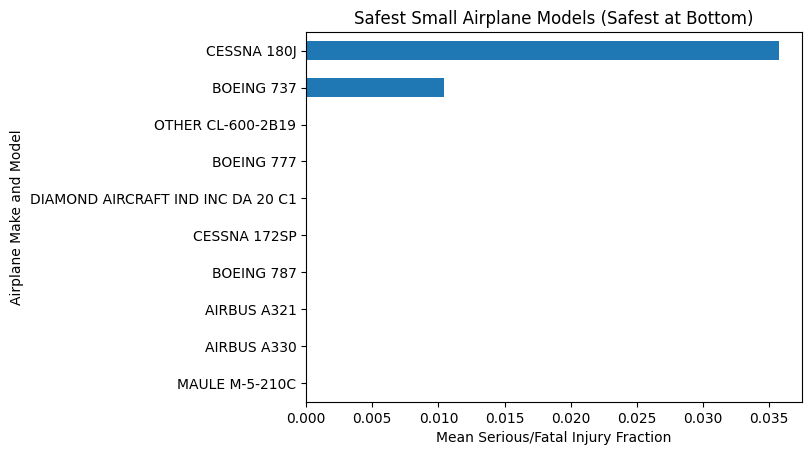

In [17]:
#Create plot:
ax = small_models_injury_risk.sort_values().plot(kind = "barh")

ax.set_title("Safest Small Airplane Models (Safest at Bottom)")
ax.set_xlabel("Mean Serious/Fatal Injury Fraction")
ax.set_ylabel("Airplane Make and Model")

#Show the plot:
plt.show()

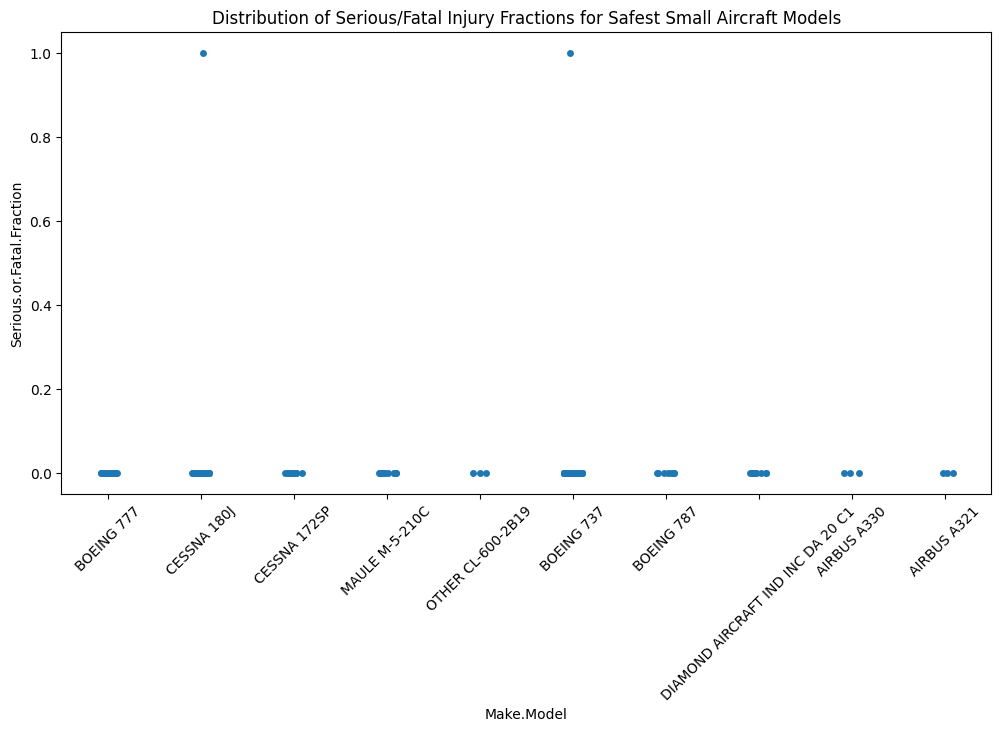

In [18]:
#First, get the ten safest small planes:
top_10_small_models = small_models_injury_risk.index

#Now, create a df that we'll use to make the strip plot:
small_strip_plot_df = plane_type_df[(plane_type_df["Airplane.Size"] == "Small") & (plane_type_df["Make.Model"].isin(top_10_small_models))]

#Now, let's make the strip plot:
plt.figure(figsize = (12, 6))
sns.stripplot(data = small_strip_plot_df, x = "Make.Model", y = "Serious.or.Fatal.Fraction")
plt.title("Distribution of Serious/Fatal Injury Fractions for Safest Small Aircraft Models")
plt.xticks(rotation = 45)
plt.show()

**Larger planes**

In [19]:
#Do the same for the top 15 large planes:
large_models_injury_risk = injury_risk_by_model_and_size["Large"].sort_values().head(15)
large_models_injury_risk

Make.Model
BOEING 757                0.000000
BOEING 777                0.000000
MCDONNELL DOUGLAS MD11    0.000000
OTHER CL-600-2B19         0.005640
BOEING 787                0.009732
BOEING 747                0.011927
BOEING 767                0.086505
BOEING 737                0.132325
DEHAVILLAND DHC-3         0.227273
AIRBUS A330               0.256611
AIRBUS A320               0.273979
AIRBUS A321               0.285714
BEECH 1900                1.000000
Name: Serious.or.Fatal.Fraction, dtype: float64

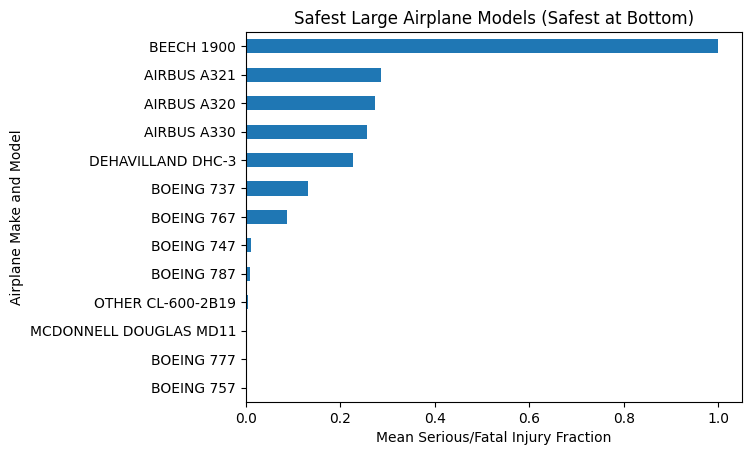

In [20]:
#Plot large airplane makes:
ax = large_models_injury_risk.sort_values().plot(kind = "barh")

ax.set_title("Safest Large Airplane Models (Safest at Bottom)")
ax.set_xlabel("Mean Serious/Fatal Injury Fraction")
ax.set_ylabel("Airplane Make and Model")

#Show the plot:
plt.show()

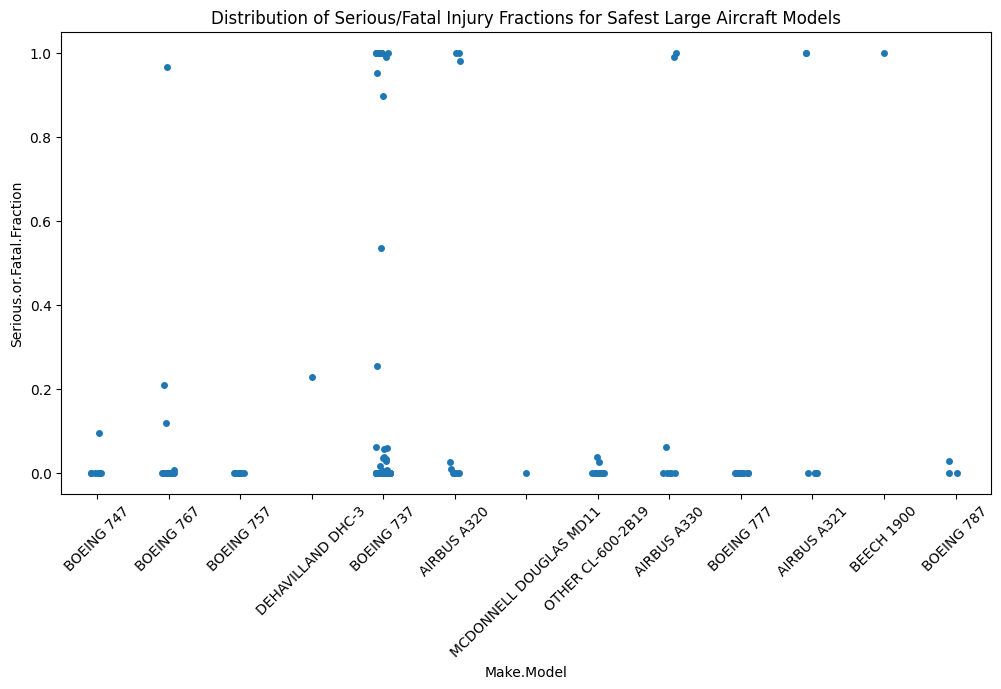

In [21]:
#First, get the ten safest large planes:
top_10_large_models = large_models_injury_risk.index

#Now, create a df that we'll use to make the strip plot:
large_strip_plot_df = plane_type_df[(plane_type_df["Airplane.Size"] == "Large") & (plane_type_df["Make.Model"].isin(top_10_large_models))]

#Now, let's make the strip plot:
plt.figure(figsize = (12, 6))
sns.stripplot(data = large_strip_plot_df, x = "Make.Model", y = "Serious.or.Fatal.Fraction")
plt.title("Distribution of Serious/Fatal Injury Fractions for Safest Large Aircraft Models")
plt.xticks(rotation = 45)
plt.show()

### Discussion of Specific Airplane Types
Discuss in markdown what you have found regarding the fatal/seriously injured fraction of passengers for both small and large airplane models.

The small airplane data is a little misleading because "small" vs. "large" planes was based off of *number of passengers on board during specific incidents*, not based on airplane *capacity*. This means there are some "small" planes that should not be treated as such, such as the Boeing 737 and Boeing 777, for example. However, it still seems that Boeing 777s, Boeing 787s, Airbus A321s, and Airbus A330s are safe for flights with few passengers ("small" flights). However, most models of small planes usually have zero serious or fatal injuries, and there are only one or two instances of many serious or fatal injuries occuring. For larger planes, Boeing still shows up strong, with many models being very safe from serious or fatal injuries. Airbus A321s, A320s, and A330s are also among the safest large plane options on average, even though they have a few more instances than Boeing does of instances with many serious or fatal injuries.

### Exploring Other Variables
Investigate how other variables affect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor, provide a discussion in markdown explaining your analysis with appropriate visualization/data summaries and interpret your findings.

### Analyzing the Impact of Weather Condition on Airplane Safety

#### Impact of Weather Condition on Serious/Fatal Injury Risk

In [22]:
#First, let's find the average risk of serious or fatal injury grouped by Weather.Condition:
injury_risk_by_weather = cleaned_df.groupby("Weather.Condition")["Serious.or.Fatal.Fraction"].mean()
injury_risk_by_weather

Weather.Condition
IMC    0.644768
UNK    0.470107
VMC    0.244499
Name: Serious.or.Fatal.Fraction, dtype: float64

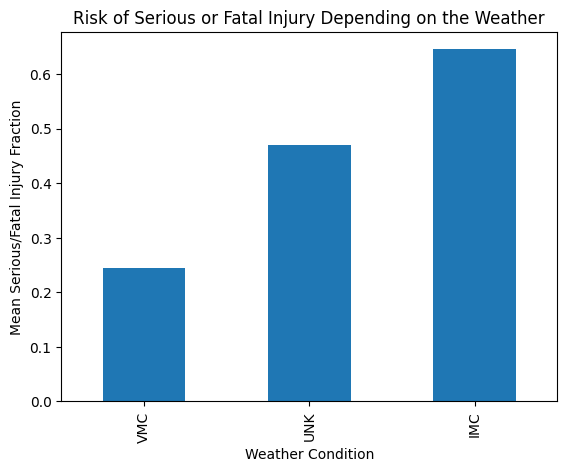

In [23]:
#Let's make a bar graph to visualize this data:
ax = injury_risk_by_weather.sort_values().plot(kind = "bar")
ax.set_title("Risk of Serious or Fatal Injury Depending on the Weather")
ax.set_xlabel("Weather Condition")
ax.set_ylabel("Mean Serious/Fatal Injury Fraction")
plt.show()

It looks like there is a much higher risk of serious or fatal injury during IMC, or instrument meteorological conditions (bad weather), which makes sense beacuse poor visibility, strong wind, and dependence solely on instruments rather than being able to see out the window all definitely lead to increased chance of a bad crash.

#### Impact of Weather Condition on Airplane Destruction Risk

In [24]:
#First, let's find the average risk of airplane destruction grouped by
#Weather.Condition:
destruction_risk_by_weather = cleaned_df.groupby("Weather.Condition")["Aircraft.Destroyed"].mean()
destruction_risk_by_weather

Weather.Condition
IMC    0.371371
UNK    0.338983
VMC    0.076450
Name: Aircraft.Destroyed, dtype: float64

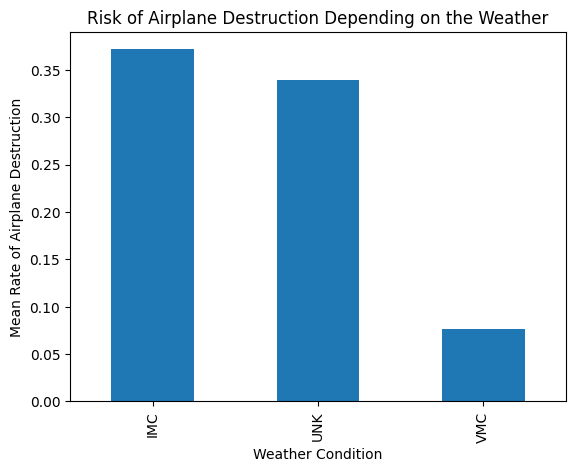

In [25]:
#Now, let's make a bar graph to visualize this data:
ax = destruction_risk_by_weather.plot(kind = "bar")
ax.set_title("Risk of Airplane Destruction Depending on the Weather")
ax.set_xlabel("Weather Condition")
ax.set_ylabel("Mean Rate of Airplane Destruction")
plt.show()

There appears also to be a higher risk of airplane destruction during accidents occuring during IMC, which again makes sense because with lower visibility and needing to rely on instruments rather than seeing out the window, there is a higher chance of more serious accidents, which logically lead to a higher risk of airplane destruction upon crashing.

### Analyzing the Impact of Phase of Flight on Airplane Safety

#### Impact of Phase of Flight on Serious/Fatal Injury Risk

In [26]:
#First, let's find the average risk of serious or fatal injury grouped by 
#Broad.phase.of.flight:
injury_risk_by_flight_phase = cleaned_df.groupby("Broad.phase.of.flight")["Serious.or.Fatal.Fraction"].mean()
injury_risk_by_flight_phase

Broad.phase.of.flight
Approach       0.220993
Climb          0.311451
Cruise         0.178831
Descent        0.249901
Go-around      0.112734
Landing        0.012295
Maneuvering    0.355755
Other          0.314680
Takeoff        0.109233
Taxi           0.009589
Name: Serious.or.Fatal.Fraction, dtype: float64

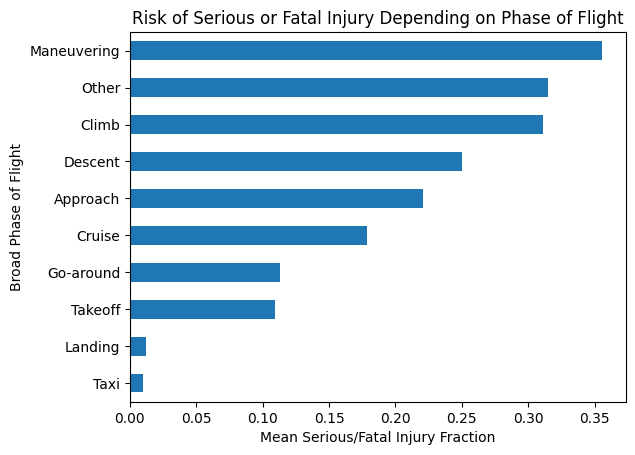

In [27]:
#Let's make a horizontal bar graph to visualize this data:
ax = injury_risk_by_flight_phase.sort_values().plot(kind = "barh")
ax.set_title("Risk of Serious or Fatal Injury Depending on Phase of Flight")
ax.set_xlabel("Mean Serious/Fatal Injury Fraction")
ax.set_ylabel("Broad Phase of Flight")
plt.show()

It looks like the highest risk of airplane accidents involving serious or fatal injuries happen during the maneuvering, climbing, descending, and approach phases. This makes sense because during these phases the airplane is usually much closer to the ground, so the pilots have a smaller reaction time in case of emergency. Also, these are phases where the pilots, who are only humans, have the most work to do, so there is a lot more risk of human error or human stress being a factor during these phases.

#### Impact of Phase of Flight on Airplane Destruction Risk

In [28]:
#First, let's find the average risk of airplane destruction grouped by
#Broad.phase.of.flight:
destruction_risk_by_flight_phase = cleaned_df.groupby("Broad.phase.of.flight")["Aircraft.Destroyed"].mean()
destruction_risk_by_flight_phase

Broad.phase.of.flight
Approach       0.125000
Climb          0.283019
Cruise         0.137255
Descent        0.184615
Go-around      0.078652
Landing        0.015139
Maneuvering    0.271084
Other          0.119407
Takeoff        0.120553
Taxi           0.009524
Name: Aircraft.Destroyed, dtype: float64

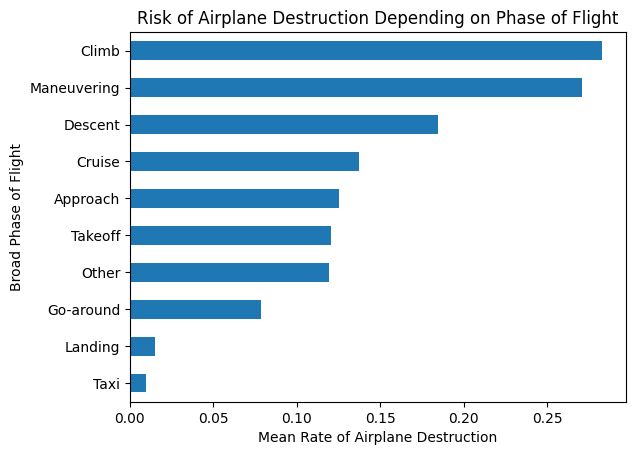

In [29]:
#Now, let's make a bar graph to visualize this data:
ax = destruction_risk_by_flight_phase.sort_values().plot(kind = "barh")
ax.set_title("Risk of Airplane Destruction Depending on Phase of Flight")
ax.set_xlabel("Mean Rate of Airplane Destruction")
ax.set_ylabel("Broad Phase of Flight")
plt.show()

The highest risk of crashes in which the airplane is destroyed occurs during the flight phases of climb, maneuvering, and descent, which again makes sense for the same reasons as the serious/fatal injury risk explanation above. What is interesting is that there is a lower chance of airplane destruction during approach compared to the injury risk during that phase. Maybe this is because when the airplane is already approaching landing, the airplane is closer to the ground, so even if it crash lands, there is a lower chance of it being completely destroyed rather than just damaged.